In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path

data_path = Path("../data/employee_attrition.csv")

if not data_path.exists():
    data_path = Path("backend/data/employee_attrition.csv")

df = pd.read_csv(data_path)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Company Experience Ratio : This tells us what proportion of an employee's total experience was spent in the current company.

In [4]:
# Ratio of years spent in the current company to total working years

df["CompanyExperienceRatio"] = np.where(
    df["TotalWorkingYears"] > 0,
    df["YearsAtCompany"] / df["TotalWorkingYears"],
    0
)

df[["TotalWorkingYears", "YearsAtCompany", "CompanyExperienceRatio"]].head()

,TotalWorkingYears,YearsAtCompany,CompanyExperienceRatio
0,8,6,0.750000
1,10,10,1.000000
2,7,0,0.000000
3,8,8,1.000000
4,6,2,0.333333


Promotion Frequency

In [5]:
# Measures how frequently an employee receives promotions during their time at the company

df["PromotionFrequency"] = np.where(
    df["YearsAtCompany"] > 0,
    df["YearsSinceLastPromotion"] / df["YearsAtCompany"],
    0
)

df[["YearsAtCompany", "YearsSinceLastPromotion", "PromotionFrequency"]].head()

,YearsAtCompany,YearsSinceLastPromotion,PromotionFrequency
0,6,0,0.000
1,10,1,0.100
2,0,0,0.000
3,8,3,0.375
4,2,2,1.000


Income Per Year of Experience

In [6]:
df["IncomePerYearExperience"] = np.where(
    df["TotalWorkingYears"] > 0,
    df["MonthlyIncome"] / df["TotalWorkingYears"],
    df["MonthlyIncome"]
)

df[[
    "MonthlyIncome",
    "TotalWorkingYears",
    "IncomePerYearExperience"
]].head()

,MonthlyIncome,TotalWorkingYears,IncomePerYearExperience
0,5993,8,749.125000
1,5130,10,513.000000
2,2090,7,298.571429
3,2909,8,363.625000
4,3468,6,578.000000


Satisfaction Score : Combine multiple satisfaction-related features:

In [8]:
satisfaction_columns = [
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance"
]

df["SatisfactionScore"] = df[satisfaction_columns].mean(axis=1)

df[satisfaction_columns + ["SatisfactionScore"]].head()

,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,WorkLifeBalance,SatisfactionScore
0,4,2,1,1,2.00
1,2,3,4,3,3.00
2,3,4,2,3,3.00
3,3,4,3,3,3.25
4,2,1,4,3,2.50


Role Tenure Ratio : This shows how much of the employee's company tenure has been spent in their current role.

In [9]:
df["RoleTenureRatio"] = np.where(
    df["YearsAtCompany"] > 0,
    df["YearsInCurrentRole"] / df["YearsAtCompany"],
    0
)

df[[
    "YearsInCurrentRole",
    "YearsAtCompany",
    "RoleTenureRatio"
]].head()

,YearsInCurrentRole,YearsAtCompany,RoleTenureRatio
0,4,6,0.666667
1,7,10,0.700000
2,0,0,0.000000
3,7,8,0.875000
4,2,2,1.000000


In [11]:
new_features = [
    "CompanyExperienceRatio",
    "PromotionFrequency",
    "IncomePerYearExperience",
    "SatisfactionScore",
    "RoleTenureRatio"
]

print("New features created:")
for feature in new_features:
    print("-", feature)

New features created:
- CompanyExperienceRatio
- PromotionFrequency
- IncomePerYearExperience
- SatisfactionScore
- RoleTenureRatio


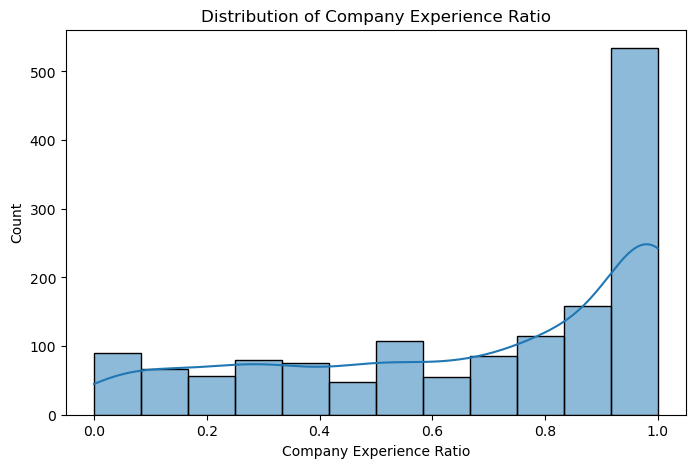

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df["CompanyExperienceRatio"], kde=True)
plt.title("Distribution of Company Experience Ratio")
plt.xlabel("Company Experience Ratio")
plt.ylabel("Count")
plt.show()

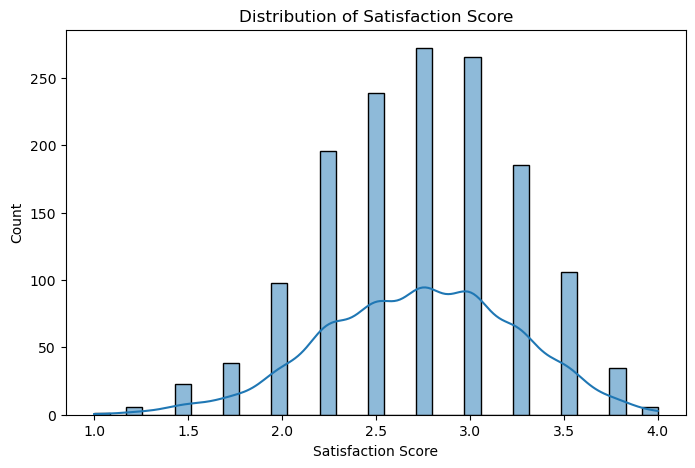

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df["SatisfactionScore"], kde=True)
plt.title("Distribution of Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Count")
plt.show()

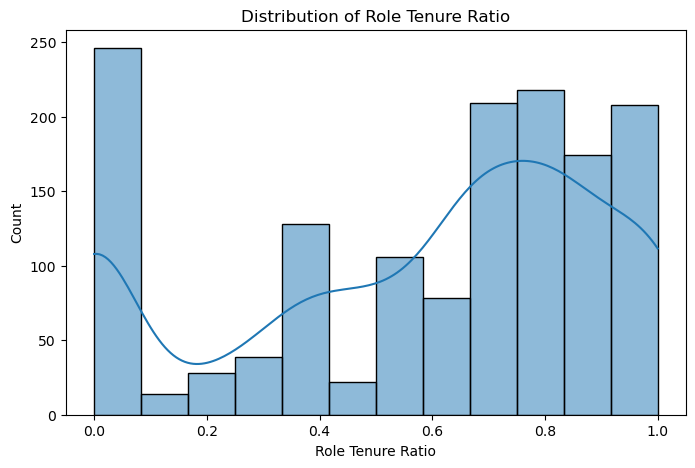

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(df["RoleTenureRatio"], kde=True)
plt.title("Distribution of Role Tenure Ratio")
plt.xlabel("Role Tenure Ratio")
plt.ylabel("Count")
plt.show()

In [15]:
print("Final dataset shape before removing unnecessary columns:", df.shape)

print("\nNew features:")
print(new_features)

Final dataset shape before removing unnecessary columns: (1470, 40)

New features:
['CompanyExperienceRatio', 'PromotionFrequency', 'IncomePerYearExperience', 'SatisfactionScore', 'RoleTenureRatio']


In [16]:
columns_to_remove = [
    "DailyRate",
    "HourlyRate",
    "MonthlyRate",
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

df.drop(columns=columns_to_remove, inplace=True)

print("Removed columns:")
for column in columns_to_remove:
    print("-", column)

print("\nFinal dataset shape:", df.shape)

Removed columns:
- DailyRate
- HourlyRate
- MonthlyRate
- EmployeeNumber
- EmployeeCount
- Over18
- StandardHours

Final dataset shape: (1470, 33)


In [17]:
print("Final columns:")
print(df.columns.tolist())

print("\nDataset shape:", df.shape)

df.head()

Final columns:
['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'CompanyExperienceRatio', 'PromotionFrequency', 'IncomePerYearExperience', 'SatisfactionScore', 'RoleTenureRatio']

Dataset shape: (1470, 33)


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,CompanyExperienceRatio,PromotionFrequency,IncomePerYearExperience,SatisfactionScore,RoleTenureRatio
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,3,...,1,6,4,0,5,0.750000,0.000,749.125000,2.00,0.666667
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,2,...,3,10,7,1,7,1.000000,0.100,513.000000,3.00,0.700000
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,4,Male,2,...,3,0,0,0,0,0.000000,0.000,298.571429,3.00,0.000000
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,3,...,3,8,7,3,0,1.000000,0.375,363.625000,3.25,0.875000
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,Male,3,...,3,2,2,2,2,0.333333,1.000,578.000000,2.50,1.000000


In [18]:
output_path = data_path.parent / "employee_attrition_feature_engineered.csv"

df.to_csv(output_path, index=False)

print("Feature-engineered dataset saved successfully!")
print("Saved at:", output_path)

Feature-engineered dataset saved successfully!
Saved at: ..\data\employee_attrition_feature_engineered.csv
